Nombre: Azucena Caicedo
Referencia: Apuntes de Felipe.

# 📘 Temas abordados

- Error absoluto  
- Error relativo  
- Forward error (error progresivo)  
- Backward error (error regresivo)  
- Diferencia entre forward y backward error  
- Relación entre error, estabilidad y condicionamiento  
- Condicionamiento de un problema  
- Condicionamiento de una matriz  
- Estabilidad de un algoritmo  
- Interpretación de errores en Python  

### Definición 12

La cantidad:

$$
K(A) := \|A\| \, \|A^{-1}\|
$$

se llama *número de condición de la matriz* $A$.

---

El número de condición de una matriz es una medida de perturbación en la solución del sistema $Ax = b$ provocada por perturbaciones en los datos $A$ o $b$. Se dice que una matriz es *mal condicionada* si $K(A)$ es "grande". El sentido de que un número de condición es grande o pequeño está dado por las aplicaciones prácticas.

De la discusión anterior conocemos que si $\bar{x}$ es solución de $Ax = b$, y $\hat{A}$ y $\hat{b}$ son los datos que contienen errores de $A$ y $b$ respectivamente, entonces:

1. 
$$
\frac{\|\bar{x} - \hat{x}_b\|}{\|x\|} \leq K(A)\,\frac{\|b - \hat{b}\|}{\|b\|}
$$
donde $\hat{x}_b$ representa la solución aproximada cuando solamente $b$ está considerado como dato.

2. 
$$
\frac{\|\bar{x} - \hat{x}_A\|}{\|x\|} \leq K(A)\,\frac{\|A - \hat{A}\|}{\|A\|}
$$
donde $\hat{x}_A$ representa la solución aproximada cuando solamente $A$ está considerado como dato.

---

Es decir, $\hat{x}_b$ es la solución de $Ax = \hat{b}$ y $\hat{x}_A$ es la solución de $\hat{A}x_A = b$.

### Observación 5

- $K(A) \geq 1.$

- $K(\alpha A) = K(A).$

- $\det(A) = 0 \Longleftrightarrow K(A) = \infty.$

- 
$$
K(A) = \frac{\max_{\|x\|=1} \|Ax\|}{\min_{\|x\|=1} \|Ax\|}
$$
generaliza el número de condición para matrices que no son cuadradas.

---

Es interesante notar que la condición de un sistema lineal recae esencialmente en la matriz $A$, incluso cuando solo el dato del lado derecho $b$ del sistema varía. En otras palabras, es la estructura de la matriz $A$ la que determina si el sistema está bien o mal condicionado.

In [1]:
import numpy as np

# =========================
# 1. Definir matriz A y vector b
# =========================
A = np.array([[2.0, 1.0],
              [1.0, 3.0]])

b = np.array([1.0, 2.0])

# =========================
# 2. Solución exacta
# =========================
x_bar = np.linalg.solve(A, b)

# =========================
# 3. Perturbación en b
# =========================
epsilon = 1e-4
b_hat = b + epsilon * np.random.randn(*b.shape)

# =========================
# 4. Solución con b perturbado
# =========================
x_hat_b = np.linalg.solve(A, b_hat)

# =========================
# 5. Número de condición
# =========================
K = np.linalg.cond(A)

# =========================
# 6. Verificar desigualdad
# =========================
lado_izq = np.linalg.norm(x_bar - x_hat_b) / np.linalg.norm(x_bar)
lado_der = K * (np.linalg.norm(b - b_hat) / np.linalg.norm(b))

# =========================
# 7. Resultados
# =========================
print("Número de condición K(A):", K)
print("Lado izquierdo:", lado_izq)
print("Lado derecho:", lado_der)
print("¿Se cumple la desigualdad?:", lado_izq <= lado_der)

Número de condición K(A): 2.6180339887498953
Lado izquierdo: 0.00031639116207082867
Lado derecho: 0.00035712394970930885
¿Se cumple la desigualdad?: True


* El lado izquierdo mide el error relativo en la solución.
* El lado derecho es la cota teórica usando el número de condición.
* Si K(A) es grande → pequeños errores en b producen grandes errores en x.

In [3]:
# =========================
# 3. Perturbación en A
# =========================
epsilon = 1e-4
A_hat = A + epsilon * np.random.randn(*A.shape)

# =========================
# 4. Solución con A perturbada
# =========================
x_hat_A = np.linalg.solve(A_hat, b)

# =========================
# 5. Número de condición
# =========================
K = np.linalg.cond(A)

# =========================
# 6. Verificar desigualdad
# =========================
lado_izq = np.linalg.norm(x_bar - x_hat_A) / np.linalg.norm(x_bar)
lado_der = K * (np.linalg.norm(A - A_hat) / np.linalg.norm(A))

# =========================
# 7. Resultados
# =========================
print("Número de condición K(A):", K)
print("Error relativo en x (lado izquierdo):", lado_izq)
print("Cota teórica (lado derecho):", lado_der)
print("¿Se cumple la desigualdad?:", lado_izq <= lado_der)

Número de condición K(A): 2.6180339887498953
Error relativo en x (lado izquierdo): 5.830732573906314e-06
Cota teórica (lado derecho): 3.7859797782692106e-05
¿Se cumple la desigualdad?: True


Podemos cambiar la condición de la matriz:

In [4]:
A = np.array([[1, 2],
              [3, 4]])

print("Condición (norma 2):", np.linalg.cond(A))
print("Condición (norma 1):", np.linalg.cond(A, 1))
print("Condición (norma infinito):", np.linalg.cond(A, np.inf))

Condición (norma 2): 14.933034373659265
Condición (norma 1): 20.999999999999996
Condición (norma infinito): 21.0


La matriz está relativamente bien condicionada, porque su número de condición no es muy grande. Sin embargo, no es una matriz perfectamente condicionada, ya que \(K(A)\) es mayor que 1.

Matrices de Hilbert $H_{ij}=\dfrac{1}{i+j+1}$

In [5]:
def hilbert_m(n):
    """ Genera una matriz de Hilbert de tamaño nxn"""
    H = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            H[i,j] = 1 / (i + j + 1)
    return H 

In [7]:
H=hilbert_m(5)
print(H)

[[1.         0.5        0.33333333 0.25       0.2       ]
 [0.5        0.33333333 0.25       0.2        0.16666667]
 [0.33333333 0.25       0.2        0.16666667 0.14285714]
 [0.25       0.2        0.16666667 0.14285714 0.125     ]
 [0.2        0.16666667 0.14285714 0.125      0.11111111]]


In [8]:
np.linalg.cond(H)

np.float64(476607.25024100044)

La matriz de Hilbert es un ejemplo clásico de matriz mal condicionada, ya que su número de condición es muy grande, lo que implica alta sensibilidad de la solución ante pequeñas perturbaciones en los datos.

In [9]:
# ============================================================
# Definimos la función f: R^2 -> R
# f(x1, x2) = x1 - x2
# ============================================================

def f(x):
    return x[0] - x[1]


# ============================================================
# Caso 1: punto a
# ============================================================

a = np.array([1.0, -1.0])
a_tilde = np.array([1.001, -0.999])

# Perturbación en los datos
delta_a = a_tilde - a

# Cambio en la salida
delta_x_a = f(a_tilde) - f(a)

# Número de condición relativo aproximado
k_a = (abs(delta_x_a) / abs(f(a))) / (np.linalg.norm(delta_a) / np.linalg.norm(a))

# Número de condición absoluto aproximado
k_abs_a = abs(delta_x_a) / np.linalg.norm(delta_a)

print("===== Caso a =====")
print("f(a) =", f(a))
print("f(a_tilde) =", f(a_tilde))
print("delta_a =", delta_a)
print("||delta_a|| =", np.linalg.norm(delta_a))
print("||delta_a|| / ||a|| =", np.linalg.norm(delta_a) / np.linalg.norm(a))
print("|delta_x| =", abs(delta_x_a))
print("k(a) aproximado =", k_a)
print("k_abs(a) aproximado =", k_abs_a)


# ============================================================
# Caso 2: punto b
# ============================================================

b = np.array([1.0, 1.0])
b_tilde = np.array([0.999, 1.001])

# Perturbación en los datos
delta_b = b_tilde - b

# Cambio en la salida
delta_x_b = f(b_tilde) - f(b)

# Como f(b) = 0, no se usa condición relativa
# Se usa condición absoluta
k_abs_b = abs(delta_x_b) / np.linalg.norm(delta_b)

print("\n===== Caso b =====")
print("f(b) =", f(b))
print("f(b_tilde) =", f(b_tilde))
print("delta_b =", delta_b)
print("||delta_b|| =", np.linalg.norm(delta_b))
print("|delta_x| =", abs(delta_x_b))
print("k_abs(b) aproximado =", k_abs_b)

===== Caso a =====
f(a) = 2.0
f(a_tilde) = 2.0
delta_a = [0.001 0.001]
||delta_a|| = 0.0014142135623730178
||delta_a|| / ||a|| = 0.0009999999999999454
|delta_x| = 0.0
k(a) aproximado = 0.0
k_abs(a) aproximado = 0.0

===== Caso b =====
f(b) = 0.0
f(b_tilde) = -0.0019999999999998908
delta_b = [-0.001  0.001]
||delta_b|| = 0.0014142135623730178
|delta_x| = 0.0019999999999998908
k_abs(b) aproximado = 1.414213562373095


En el punto $a=(1,-1)$, la perturbación escogida no cambia el valor de la función, por eso $k(a)=0$.

En el punto $b=(1,1)$, como $f(b)=0$, no se puede usar el número de condición relativo. Por eso se usa el número de condición absoluto, obteniendo aproximadamente:

$$
k_{abs}(b) \approx 1.41423.
$$

## ⚖️ Diferencia clave

| Concepto | Número de condición de un problema | Número de condición de una matriz |
|----------|----------------------------------|----------------------------------|
| Qué mide | Sensibilidad de cualquier problema | Sensibilidad de sistemas lineales |
| Generalidad | Muy general | Caso particular |
| Objeto | Función $F(d)$ | Matriz $A$ |
| Ejemplo | $f(x)$, PDE, optimización | $Ax = b$ |
| Fórmula | $\displaystyle k(d) = \sup_{\delta d} \frac{\|\delta x\| / \|x\|}{\|\delta d\| / \|d\|}$ | $\displaystyle K(A) = \|A\|\,\|A^{-1}\|$ |

El condicionamiento mide la sensibilidad del problema, mientras que la estabilidad mide cómo un algoritmo propaga los errores numéricos.

# 📘 Estabilidad y Convergencia (Resumen para Python)

## 🔴 1. Estabilidad de un método numérico

Un método es **estable** si:

- Existe solución única $x_n$ para cada dato $d_n$
- La solución depende continuamente de los datos

Formalmente:

$$
\|\delta x_n\| \leq K_n \|\delta d_n\|
$$

👉 Interpretación:

> Pequeños errores en los datos producen pequeños errores en la solución.

---

## 🔵 2. Consistencia

Un método es **consistente** si aproxima bien el problema original:

$$
F_n(x, d) - F(x, d) \to 0 \quad \text{cuando } n \to \infty
$$

👉 Interpretación:

> El método se parece cada vez más al problema real.

---

## 🟢 3. Convergencia

Un método es **convergente** si:

$$
x_n \to x \quad \text{cuando } n \to \infty
$$

Incluso con pequeñas perturbaciones en los datos.

👉 Interpretación:

> La solución numérica se acerca a la solución exacta.

---

## ⚖️ 4. Relación clave

```markdown
Consistencia + Estabilidad  ⇔  Convergencia

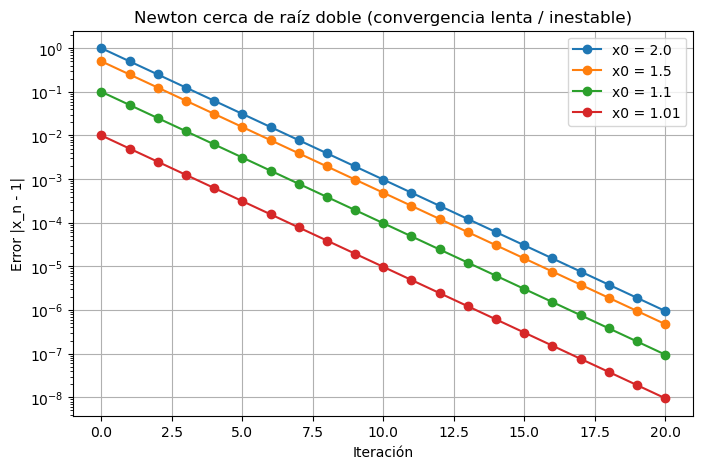

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# EJEMPLO: Newton cerca de raíz doble
# f(x) = (x - 1)^2  → raíz doble en x = 1
# ============================================================

def f(x):
    return (x - 1)**2

def df(x):
    return 2*(x - 1)

# ============================================================
# Método de Newton
# ============================================================

def newton(x0, max_iter=20):
    xs = [x0]
    
    for i in range(max_iter):
        if abs(df(x0)) < 1e-12:  # evitar división por cero
            print("Derivada muy pequeña, posible inestabilidad")
            break
        
        x1 = x0 - f(x0)/df(x0)
        xs.append(x1)
        x0 = x1
    
    return np.array(xs)

# ============================================================
# Probar con diferentes puntos iniciales
# ============================================================

x0_vals = [2.0, 1.5, 1.1, 1.01]

plt.figure(figsize=(8,5))

for x0 in x0_vals:
    xs = newton(x0)
    errors = np.abs(xs - 1)  # error respecto a la raíz
    
    plt.plot(errors, marker='o', label=f'x0 = {x0}')
#Grafica
plt.yscale('log')
plt.xlabel('Iteración')
plt.ylabel('Error |x_n - 1|')
plt.title('Newton cerca de raíz doble (convergencia lenta / inestable)')
plt.legend()
plt.grid()
plt.show()

## 🔧 ¿Qué hace el algoritmo?

El código implementa el **método de Newton** para encontrar la raíz de la función:

$$
f(x) = (x - 1)^2
$$

El método itera usando:

$$
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}
$$

En cada iteración:

- Se calcula una nueva aproximación de la raíz
- Se almacena la secuencia de valores $x_n$
- Se mide el error respecto a la raíz real $x = 1$

Además, se prueban distintos puntos iniciales $x_0$ para analizar el comportamiento del método.

---

## 📊 ¿Qué muestra la gráfica?

La gráfica representa:

- Eje horizontal: número de iteraciones
- Eje vertical: error $|x_n - 1|$ en escala logarítmica

Cada curva corresponde a un punto inicial distinto.

---

## 🔎 Interpretación de los resultados

### 🔴 Raíz doble

Para la función:

$$
f(x) = (x - 1)^2
$$

la raíz en $x = 1$ es **doble**, lo que implica:

- El método de Newton **no converge cuadráticamente**
- La convergencia es **lineal (más lenta)**

---

### 🔵 Comportamiento observado

- El error disminuye, pero **más lentamente** que en el caso ideal
- Las curvas en la gráfica muestran una pendiente menos pronunciada
- Mientras más cerca esté el punto inicial de la raíz:
  - La derivada $f'(x)$ es muy pequeña
  - Se generan **problemas numéricos**

---

## ⚠️ Conclusión importante

```markdown
El método de Newton pierde eficiencia y estabilidad cerca de raíces múltiples, ya que la derivada se aproxima a cero, lo que provoca una convergencia más lenta y posibles problemas numéricos.

# 📘 Errores en Análisis Numérico (Python)

## 🔴 Error absoluto

Si $x$ es la solución exacta y $x_n$ la aproximada, el error absoluto es:

$$
E(x_n) = \|x - x_n\|
$$

**Interpretación:**
- Mide la diferencia directa entre la solución exacta y la aproximada.
- No considera la escala del problema.

**En Python:**
```python
np.linalg.norm(x - xn)

In [4]:
import numpy as np

# solución exacta
x = np.array([1.0, 2.0])

# solución aproximada
xn = np.array([0.9, 2.1])

# cálculo del error absoluto
error_abs = np.linalg.norm(x - xn)

print("Error absoluto:", error_abs)

Error absoluto: 0.14142135623730953


## 🔵 Error relativo

El **error relativo** mide el error en relación al tamaño de la solución exacta.

Se define como:

$$
E_{rel}(x_n) = \frac{\|x - x_n\|}{\|x\|}
$$

donde:
- $x$ = solución exacta  
- $x_n$ = solución aproximada  

---

### 💡 Interpretación

- Indica **qué tan grande es el error en proporción al valor real**.
- Es más útil que el error absoluto cuando los valores son muy grandes o muy pequeños.
- Permite comparar errores en diferentes problemas.

---

### 🐍 Ejemplo en Python

```python


In [5]:
import numpy as np

# solución exacta
x = np.array([1.0, 2.0])

# solución aproximada
xn = np.array([0.9, 2.1])

# cálculo del error relativo
error_rel = np.linalg.norm(x - xn) / np.linalg.norm(x)

print("Error relativo:", error_rel)

Error relativo: 0.0632455532033676


## 🟢 Forward Error (Error progresivo)

El **forward error** mide el error directamente en la solución:

$$
\|x - \hat{x}\|
$$

donde:
- $x$ = solución exacta  
- $\hat{x}$ = solución calculada  

---

### 💡 Interpretación

- Mide **qué tan lejos está la solución numérica de la solución real**.
- Es el error que normalmente queremos minimizar.
- Depende tanto del algoritmo como del condicionamiento del problema.

---

### 🐍 Ejemplo en Python

```python


In [6]:
import numpy as np

# solución exacta
x = np.array([1.0, 2.0])

# solución aproximada
x_hat = np.array([0.9, 2.1])

forward_error = np.linalg.norm(x - x_hat)

print("Forward error:", forward_error)

Forward error: 0.14142135623730953


El forward error indica qué tan lejos está la solución aproximada de la solución exacta. 
En este caso, la diferencia es pequeña, lo que significa que la aproximación es buena.

In [7]:
import numpy as np

# matriz del sistema
A = np.array([[2.0, 1.0],
              [1.0, 3.0]])

# solución aproximada
x_hat = np.array([0.9, 2.1])

# dato exacto asociado a esa solución
b_tilde = A @ x_hat

print("b perturbado (backward):", b_tilde)

b perturbado (backward): [3.9 7.2]


El backward error construye un nuevo dato (b̃) para el cual la solución aproximada x̂ es exacta.

Esto significa que el algoritmo no resolvió exactamente el problema original Ax = b,
sino un problema ligeramente perturbado Ax = b̃.

Si la diferencia entre b y b̃ es pequeña, entonces el algoritmo es numéricamente estable.

## ⚖️ Diferencia clave

| Tipo de error   | Qué mide                |
|-----------------|------------------------|
| Forward error   | Error en la solución   |
| Backward error  | Error en los datos     |

---



**Conclusión**

El forward error mide el error en la solución obtenida,
mientras que el backward error mide cuánto habría que modificar los datos
para que la solución calculada sea exacta.